First, let's decompress the `admission.csv.zip`, `patients.csv.zip`, and `diagnoses_icd.csv.zip` files. We'll use `gunzip` for `chartevents.csv.gz`.

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

DATA_PATH = '/content/drive/MyDrive/dataset/'

REQUIRED_FILES = [
    'admissions.csv.zip',
    'patients.csv.zip',
    'diagnoses_icd.csv.zip',
    'chartevents.csv.gz',
]

print("Checking files...")
for f in REQUIRED_FILES:
    full = os.path.join(DATA_PATH, f)
    size = os.path.getsize(full) / (1024**2) if os.path.exists(full) else None
    status = f"  FOUND ({size:.1f} MB)" if size else "  MISSING"
    print(f"{f}{status}")



Mounted at /content/drive
Checking files...
admissions.csv.zip  FOUND (19.0 MB)
patients.csv.zip  FOUND (2.7 MB)
diagnoses_icd.csv.zip  FOUND (32.0 MB)
chartevents.csv.gz  FOUND (3340.1 MB)


Now, let's load each uncompressed CSV file into a pandas DataFrame and display the first 5 rows to understand their structure.

In [ ]:
import pandas as pd
import zipfile

def load_zip_csv(filename):
    path = os.path.join(DATA_PATH, filename)
    print(f"Loading {filename}...", end=" ")
    with zipfile.ZipFile(path, 'r') as z:
        csv_name = [f for f in z.namelist()
                    if f.endswith('.csv') and not f.startswith('__MACOSX')][0]
        df = pd.read_csv(z.open(csv_name), low_memory=False)
    print(f"Done. Shape: {df.shape}")
    return df

admissions_df  = load_zip_csv('admissions.csv.zip')
patients_df    = load_zip_csv('patients.csv.zip')
diagnoses_df   = load_zip_csv('diagnoses_icd.csv.zip')

print("\nColumn preview:")
for name, df in [("admissions", admissions_df),
                 ("patients",   patients_df),
                 ("diagnoses",  diagnoses_df)]:
    print(f"  {name}: {list(df.columns)}")


Loading admissions.csv.zip... Done. Shape: (546028, 16)
Loading patients.csv.zip... Done. Shape: (364627, 6)
Loading diagnoses_icd.csv.zip... Done. Shape: (6364488, 5)

Column preview:
  admissions: ['subject_id', 'hadm_id', 'admittime', 'dischtime', 'deathtime', 'admission_type', 'admit_provider_id', 'admission_location', 'discharge_location', 'insurance', 'language', 'marital_status', 'race', 'edregtime', 'edouttime', 'hospital_expire_flag']
  patients: ['subject_id', 'gender', 'anchor_age', 'anchor_year', 'anchor_year_group', 'dod']
  diagnoses: ['subject_id', 'hadm_id', 'seq_num', 'icd_code', 'icd_version']


In [ ]:

import numpy as np

VITAL_ITEM_IDS = {
    220045: 'heart_rate',  220179: 'sbp',          220180: 'dbp',
    220277: 'spo2',        220210: 'resp_rate',
    223761: 'temp_f',      223762: 'temp_c',
    220739: 'gcs_eye',     223900: 'gcs_verbal',   223901: 'gcs_motor',
    224167: 'sbp_arterial',228232: 'dbp_arterial',
    220050: 'sbp_arterial2',220051: 'dbp_arterial2',
    226512: 'weight_kg',   226730: 'height_cm',
}
VITAL_IDS_SET = set(VITAL_ITEM_IDS.keys())

#  using chunk of data

FILTERED_SAVE_PATH = os.path.join(DATA_PATH, 'filtered_chartevents.csv')

if not os.path.exists(FILTERED_SAVE_PATH):
    print("Filtered file nahi mila — chunked reading shuru hoti hai...")
    print("Yeh 20-40 min le sakta hai. Ek baar hoga, Drive pe save ho jayega.\n")

    total_rows  = 0
    kept_rows   = 0
    first_chunk = True

    for chunk in pd.read_csv(
        os.path.join(DATA_PATH, 'chartevents.csv.gz'),
        compression='gzip',
        chunksize=500_000,          # 500k rows = ~200MB RAM per chunk (free Colab safe)
        low_memory=False,
        usecols=['subject_id', 'hadm_id', 'itemid', 'valuenum', 'charttime'],
        dtype={'subject_id': 'int32', 'hadm_id': 'float32',
               'itemid':     'int32', 'valuenum': 'float32'}
    ):
        filtered = chunk[chunk['itemid'].isin(VITAL_IDS_SET)].copy()

        if len(filtered) > 0:
            # Turant Drive pe likhte jao — memory mein mat rakho
            filtered.to_csv(
                FILTERED_SAVE_PATH,
                mode='w' if first_chunk else 'a',
                index=False,
                header=first_chunk
            )
            first_chunk  = False
            kept_rows   += len(filtered)

        total_rows += len(chunk)
        print(f"  {total_rows/1e6:.1f}M rows scanned | {kept_rows:,} vital rows Drive pe saved", end='\r')

    saved_mb = os.path.getsize(FILTERED_SAVE_PATH) / (1024**2)
    print(f"\n\nComplete! File saved: {FILTERED_SAVE_PATH} ({saved_mb:.1f} MB)")

else:
    saved_mb = os.path.getsize(FILTERED_SAVE_PATH) / (1024**2)
    print(f"filtered_chartevents.csv already exists ({saved_mb:.1f} MB) — seedha load kar raha hoon...")

# only use small filtered value
chartevents_raw = pd.read_csv(FILTERED_SAVE_PATH, low_memory=False)
chartevents_raw['vital_name'] = chartevents_raw['itemid'].map(VITAL_ITEM_IDS)
print(f"Loaded. Shape: {chartevents_raw.shape}")


Filtered file nahi mila — chunked reading shuru hoti hai...
Yeh 20-40 min le sakta hai. Ek baar hoga, Drive pe save ho jayega.

  433.0M rows scanned | 52,099,964 vital rows Drive pe saved

Complete! File saved: /content/drive/MyDrive/dataset/filtered_chartevents.csv (2587.8 MB)
Loaded. Shape: (52099964, 6)


### Handling Vitals (Chartevents)
The `chartevents` table contains thousands of different measurement types identified by `itemid`. For a triage system, we specifically need:
- **Heart Rate**: `itemid` 220045
- **O2 Saturation**: `itemid` 220277
- **Systolic BP**: `itemid` 220179
- **Temperature**: `itemid` 223762

I will generate code to extract these specific features for each patient.

In [ ]:
chartevents_raw.loc[
    chartevents_raw['vital_name'].isin(['sbp_arterial','sbp_arterial2']),
    'vital_name'
] = 'sbp'
chartevents_raw.loc[
    chartevents_raw['vital_name'].isin(['dbp_arterial','dbp_arterial2']),
    'vital_name'
] = 'dbp'

# Convert Celsius to Fahrenheit where needed
mask_c = chartevents_raw['vital_name'] == 'temp_c'
chartevents_raw.loc[mask_c, 'valuenum'] = \
    chartevents_raw.loc[mask_c, 'valuenum'] * 9/5 + 32
chartevents_raw.loc[mask_c, 'vital_name'] = 'temp_f'

# Sort by charttime to ensure 'first' = earliest measurement
chartevents_raw['charttime'] = pd.to_datetime(chartevents_raw['charttime'])
chartevents_raw = chartevents_raw.sort_values('charttime')

# Aggregate: first (triage presentation) + min/max/mean (for range features)
agg_funcs = {
    'heart_rate':  ['first', 'mean', 'min', 'max'],
    'sbp':         ['first', 'mean', 'min', 'max'],
    'dbp':         ['first', 'mean', 'min', 'max'],
    'spo2':        ['first', 'mean', 'min'],
    'temp_f':      ['first', 'mean', 'min', 'max'],
    'resp_rate':   ['first', 'mean', 'min', 'max'],
    'gcs_eye':     ['first', 'min'],
    'gcs_verbal':  ['first', 'min'],
    'gcs_motor':   ['first', 'min'],
    'weight_kg':   ['first'],
    'height_cm':   ['first'],
}

# Pivot so each vital_name becomes a column, then aggregate
vitals_long = chartevents_raw[
    chartevents_raw['vital_name'].isin(agg_funcs.keys())
].copy()

vitals_agg = (
    vitals_long
    .groupby(['subject_id', 'hadm_id', 'vital_name'])['valuenum']
    .agg(['first', 'mean', 'min', 'max'])
    .unstack('vital_name')
)

# Flatten multi-level columns: ('first','heart_rate') → 'heart_rate_first'
vitals_agg.columns = [f"{vital}_{stat}" for stat, vital in vitals_agg.columns]
vitals_agg = vitals_agg.reset_index()

print(f"Vitals aggregated. Shape: {vitals_agg.shape}")
print("Columns:", list(vitals_agg.columns[:20]), "...")


Vitals aggregated. Shape: (85242, 46)
Columns: ['subject_id', 'hadm_id', 'dbp_first', 'gcs_eye_first', 'gcs_motor_first', 'gcs_verbal_first', 'heart_rate_first', 'height_cm_first', 'resp_rate_first', 'sbp_first', 'spo2_first', 'temp_f_first', 'weight_kg_first', 'dbp_mean', 'gcs_eye_mean', 'gcs_motor_mean', 'gcs_verbal_mean', 'heart_rate_mean', 'height_cm_mean', 'resp_rate_mean'] ...


In [ ]:
# ══════════════════════════════════════════════════════════════
#  SYSTEM 1 — CARDIOVASCULAR
# ══════════════════════════════════════════════════════════════
CARDIO_CRITICAL = [
    'I200','I21','I22',          # STEMI / NSTEMI / MI
    'I260',                       # Pulmonary embolism with acute cor pulmonale
    'I440','I441','I442',         # AV block complete (3rd degree)
    'I450','I451',                # Bundle branch block with haemodynamic compromise
    'I460','I461','I469',         # Cardiac arrest
    'I470',                       # Ventricular tachycardia
    'I490',                       # Ventricular fibrillation
    'I500','I501',                # Acute systolic / diastolic heart failure
    'I710','I711','I712',         # Aortic aneurysm ruptured / dissection
]
CARDIO_URGENT = [
    'I10','I11','I12','I13',      # Hypertensive emergency / disease
    'I20',                        # Unstable / stable angina
    'I25',                        # Chronic IHD with acute worsening
    'I26',                        # Pulmonary embolism (without shock)
    'I42','I43',                  # Cardiomyopathy
    'I47','I48','I49',            # SVT / AF / arrhythmias (non-arrest)
    'I50',                        # Heart failure (sub-acute)
    'I51',                        # Complications of heart disease
]

In [ ]:
# ══════════════════════════════════════════════════════════════
#  SYSTEM 2 — NEUROLOGICAL
# ══════════════════════════════════════════════════════════════
NEURO_CRITICAL = [
    'I60','I61','I62',            # Subarachnoid / intracerebral / subdural haemorrhage
    'I63','I64','I65','I66',      # Ischaemic stroke / cerebral infarction
    'G04',                        # Encephalitis / meningitis
    'G411','G412','G419',         # Status epilepticus (convulsive & non-convulsive)
    'G930','G931',                # Cerebral oedema / compression
    'G936',                       # Brain death
]
NEURO_URGENT = [
    'G40',                        # Epilepsy (single seizure, post-ictal)
    'G43','G44',                  # Migraine / cluster headache
    'G45',                        # TIA (transient ischaemic attack)
    'G54','G55',                  # Nerve root / plexus disorders
    'G61',                        # Guillain-Barré syndrome
    'G62',                        # Other polyneuropathies
    'G93',                        # Other brain disorders (raised ICP, etc.)
    'R55',                        # Syncope (cardiac-cause workup needed)
]


In [ ]:
# ══════════════════════════════════════════════════════════════
#  SYSTEM 3 — RESPIRATORY
# ══════════════════════════════════════════════════════════════
RESP_CRITICAL = [
    'J80',                        # ARDS
    'J81',                        # Pulmonary oedema
    'J960','J961','J969',         # Acute / chronic respiratory failure
]
RESP_URGENT = [
    'J12','J13','J14','J15',      # Viral / bacterial / aspiration pneumonia
    'J18',                        # Unspecified pneumonia
    'J20','J21','J22',            # Acute bronchitis / lower resp infection
    'J44',                        # COPD acute exacerbation
    'J450','J451','J459',         # Asthma (moderate–severe)
    'J68','J69',                  # Chemical / aspiration pneumonitis
    'J86',                        # Pyothorax / empyema
    'J90','J91',                  # Pleural effusion
    'J93',                        # Pneumothorax (spontaneous)
]


In [ ]:
# ══════════════════════════════════════════════════════════════
#  SYSTEM 4 — SEPSIS & INFECTION
# ══════════════════════════════════════════════════════════════
SEPSIS_CRITICAL = [
    'A390','A391','A392','A393',  # Meningococcal septicaemia / meningitis
    'A400','A401','A408','A409',  # Streptococcal sepsis
    'A410','A411','A412','A413',  # Staphylococcal / gram-neg / other sepsis
    'A418','A419',                # Other / unspecified sepsis (septicaemia)
    'B004',                       # Herpetic encephalitis
    'B160','B161',                # Acute hepatitis B with delta (fulminant)
]
SEPSIS_URGENT = [
    'A02','A04','A05',            # Salmonella / E.coli / bacterial food poisoning
    'A09',                        # Infectious gastroenteritis
    'A41',                        # Sepsis (without shock — lower severity)
    'B34',                        # Viral infection unspecified (systemic)
    'L03','L04',                  # Cellulitis / lymphadenitis (spreading)
    'M00',                        # Septic arthritis
    'N10',                        # Acute pyelonephritis
]


In [ ]:
# ══════════════════════════════════════════════════════════════
#  SYSTEM 5 — ENDOCRINE & METABOLIC
# ══════════════════════════════════════════════════════════════
ENDO_CRITICAL = [
    'E055',                       # Thyroid storm
    'E101','E111','E121','E131','E141',  # DKA with coma (all DM types)
    'E150',                       # Hypoglycaemic coma
    'E271',                       # Addisonian / adrenal crisis
    'E274',                       # Other / unspecified adrenocortical insufficiency
    'E860',                       # Depletion of volume (severe)
    'E876',                       # Hypokalaemia (severe — cardiac risk)
    'E875',                       # Hyperkalaemia (severe — cardiac risk)
    'E870',                       # Hyperosmolality / hypernatraemia
    'E871',                       # Hypo-osmolality / hyponatraemia (severe)
]
ENDO_URGENT = [
    'E03','E04','E05',            # Thyroid disorders (non-storm)
    'E10','E11','E12','E13','E14',# Diabetes mellitus (complications, non-coma)
    'E16',                        # Other glycaemia disorders
    'E21','E22','E23',            # Parathyroid / pituitary disorders
    'E27',                        # Other adrenal disorders
    'E46',                        # Unspecified protein-energy malnutrition
    'E83','E84',                  # Mineral metabolism disorders
    'E86','E87','E88',            # Volume / electrolyte / metabolic disorders
]

In [ ]:
# ══════════════════════════════════════════════════════════════
#  SYSTEM 6 — GASTROINTESTINAL
# ══════════════════════════════════════════════════════════════
GI_CRITICAL = [
    'K250','K252','K254','K256',  # Gastric ulcer with haemorrhage / perforation
    'K260','K262','K264','K266',  # Duodenal ulcer with haemorrhage / perforation
    'K270','K272',                # Peptic ulcer with haemorrhage / perforation
    'K550','K551',                # Acute vascular insufficiency of intestine / ischaemia
    'K650','K651','K658','K659',  # Peritonitis (generalised / localised)
    'K660',                       # Haemoperitoneum
]
GI_URGENT = [
    'K35','K36','K37',            # Acute appendicitis (with / without perforation)
    'K40','K41','K42','K43',      # Hernias with obstruction
    'K56',                        # Paralytic ileus / intestinal obstruction
    'K57',                        # Diverticular disease (with / without perforation)
    'K71',                        # Toxic liver disease
    'K72',                        # Hepatic failure
    'K80','K81','K82','K83',      # Gallbladder / bile duct disease (acute)
    'K85','K86',                  # Acute / chronic pancreatitis (acute episode)
    'K92',                        # GI haemorrhage (haematemesis / melaena)
]


In [ ]:
# ══════════════════════════════════════════════════════════════
#  SYSTEM 7 — RENAL & UROLOGICAL
# ══════════════════════════════════════════════════════════════
RENAL_CRITICAL = [
    'N170','N171','N172','N178','N179',  # Acute kidney injury (all stages)
    'N185',                               # CKD stage 5 (ESRD) — acute crisis
]
RENAL_URGENT = [
    'N10',                        # Acute pyelonephritis
    'N17','N18','N19',            # Kidney failure (sub-acute / chronic worsening)
    'N20','N21',                  # Calculus of kidney / ureter (renal colic)
    'N30',                        # Cystitis (with systemic symptoms)
    'N390',                       # UTI (unspecified)
    'N40',                        # Benign prostatic hyperplasia with retention
]


In [ ]:
# ══════════════════════════════════════════════════════════════
#  SYSTEM 8 — HEMATOLOGICAL & ONCOLOGICAL
# ══════════════════════════════════════════════════════════════
HAEM_CRITICAL = [
    'D65',                        # DIC (disseminated intravascular coagulation)
    'D700','D701','D702','D703',  # Agranulocytosis / neutropenia (severe)
]
HAEM_URGENT = [
    'C91','C92','C93','C94','C95','C96',  # Leukaemia / lymphoma complications
    'D50','D51','D52','D53',      # Anaemia (nutritional / haemolytic)
    'D55','D56','D57','D58',      # Haemolytic anaemia / sickle cell crisis
    'D59','D60','D61','D62',      # Aplastic / haemolytic / haemorrhagic anaemia
    'D63','D64',                  # Anaemia in chronic disease
    'D68','D69',                  # Coagulation defects / purpura (ITP / TTP)
    'D70','D71','D72',            # Neutropenia / leukocyte disorders
]

In [ ]:
# ══════════════════════════════════════════════════════════════
#  SYSTEM 9 — OBSTETRIC & GYNAECOLOGICAL
# ══════════════════════════════════════════════════════════════
OBS_CRITICAL = [
    'O000','O001','O008','O009',  # Ectopic pregnancy (ruptured)
    'O150','O151','O159',         # Eclampsia (antepartum / intrapartum / postpartum)
    'O720','O721','O722','O723',  # Postpartum haemorrhage
    'O750',                       # Maternal distress during labour
]
OBS_URGENT = [
    'O00',                        # Ectopic pregnancy (unruptured)
    'O14',                        # Pre-eclampsia (moderate–severe)
    'O20','O21',                  # Haemorrhage / vomiting in early pregnancy
    'O22',                        # Venous complications in pregnancy
    'O36',                        # Maternal care for foetal problems
    'O46',                        # Antepartum haemorrhage
    'N73','N74',                  # Pelvic inflammatory disease / salpingitis
    'N80','N83',                  # Endometriosis / ovarian cyst (torsion risk)
]


In [ ]:
# ══════════════════════════════════════════════════════════════
#  SYSTEM 10 — PSYCHIATRIC & TOXICOLOGY
# ══════════════════════════════════════════════════════════════
PSY_CRITICAL = [
    'T400','T401','T402','T403','T404',  # Opioid overdose (heroin / synthetic)
    'T436',                               # Psychostimulant poisoning
    'T4X',                                # (covered by T-range below)
    'T710','T711','T714','T719',          # Asphyxiation / strangulation
    'T65',                                # Toxic effects of other substances
    'X60','X61','X62','X63','X64',        # Intentional self-poisoning (ICD-10 external)
]
PSY_URGENT = [
    'F10','F11','F12','F13','F14','F15','F16','F18','F19',  # Substance intoxication / withdrawal
    'F20','F21','F22','F23','F24','F25','F28','F29',         # Schizophrenia / psychosis (acute)
    'F30','F31',                          # Mania / bipolar episode (acute)
    'F43',                                # Acute stress reaction / PTSD
    'T36','T37','T38','T39',              # Poisoning by drugs (non-opioid, non-critical)
    'T41','T42','T43','T44','T45',        # Anaesthetic / antiepileptic / psychotropic poisoning
    'T46','T47','T48','T49','T50',        # Cardiovascular / GI / systemic agent poisoning
]


In [ ]:
# ══════════════════════════════════════════════════════════════
#  SYSTEM 11 — TRAUMA & EXTERNAL INJURY
# ══════════════════════════════════════════════════════════════
TRAUMA_CRITICAL = [
    'S060','S061','S062','S063','S064','S065','S066','S067','S068','S069',  # TBI (all types)
    'S270','S271','S272','S273','S274','S275','S276','S278','S279',          # Chest trauma (haemopneumothorax)
    'S350','S351','S352','S353','S354','S355','S358','S359',                  # Abdominal vascular injury
    'S360','S361','S362','S363','S365','S366','S368','S369',                  # Abdominal organ injury
    'S720','S721','S722',                 # Femur fracture (with haemorrhage risk)
    'T790','T791','T792','T794',          # Traumatic shock / air embolism
    'T14',                                # Multiple unspecified injuries
]
TRAUMA_URGENT = [
    'S00','S01','S02','S03','S04','S05',  # Head / face injuries (minor–moderate)
    'S10','S11','S12','S13','S14',        # Neck injuries / cervical spine
    'S20','S21','S22','S23','S24','S25','S26','S27','S28','S29',  # Thorax (rib / sternum)
    'S30','S31','S32','S33','S34','S35','S36','S37','S38','S39',  # Abdomen / pelvis
    'S40','S41','S42','S43','S49',        # Shoulder / upper arm
    'S50','S51','S52','S53','S59',        # Forearm / elbow / wrist fractures
    'S60','S61','S62','S63','S69',        # Hand / finger fractures / lacerations
    'S70','S71','S72','S73','S79',        # Hip / thigh (non-femur or minor)
    'S80','S81','S82','S83','S89',        # Knee / leg / tibia fractures
    'S90','S91','S92','S93','S99',        # Ankle / foot injuries
    'T20','T21','T22','T23','T24','T25','T26',  # Burns (face / torso / limbs)
    'T31','T32',                          # Burns by extent (>20% BSA → Urgent/Critical)
]

In [ ]:
# ══════════════════════════════════════════════════════════════
#  SYSTEM 12 — MUSCULOSKELETAL & SKIN
# ══════════════════════════════════════════════════════════════
MSK_URGENT = [
    'L00',                        # Staphylococcal scalded skin syndrome
    'L01','L02','L03','L04','L08',# Skin / soft tissue infections
    'M00','M01',                  # Septic arthritis
    'M54',                        # Spinal pain (with red flags — cord compression risk)
    'M65','M71',                  # Synovitis / bursitis (infected)
    'M79',                        # Soft tissue disorders (compartment syndrome risk)
    'M86','M87',                  # Osteomyelitis / osteonecrosis
]
# M25 / M54 without red flags = Stable (falls through to default)


In [ ]:
# ══════════════════════════════════════════════════════════════
#  BUILD FINAL LOOKUP SETS
#  (sets are O(1) lookup — faster than nested loops)
# ══════════════════════════════════════════════════════════════

ALL_CRITICAL_PREFIXES = set(
    CARDIO_CRITICAL + NEURO_CRITICAL + RESP_CRITICAL +
    SEPSIS_CRITICAL + ENDO_CRITICAL  + GI_CRITICAL   +
    RENAL_CRITICAL  + HAEM_CRITICAL  + OBS_CRITICAL  +
    PSY_CRITICAL    + TRAUMA_CRITICAL
)

ALL_URGENT_PREFIXES = set(
    CARDIO_URGENT + NEURO_URGENT + RESP_URGENT +
    SEPSIS_URGENT + ENDO_URGENT  + GI_URGENT   +
    RENAL_URGENT  + HAEM_URGENT  + OBS_URGENT  +
    PSY_URGENT    + TRAUMA_URGENT + MSK_URGENT
)

print(f"Critical prefixes loaded : {len(ALL_CRITICAL_PREFIXES)}")
print(f"Urgent  prefixes loaded  : {len(ALL_URGENT_PREFIXES)}")

def code_matches(code, prefix_set):
    """Return True if ICD code starts with any prefix in the set."""
    for prefix in prefix_set:
        if code.startswith(prefix):
            return True
    return False

def assign_triage_label(icd_code_list):
    """
    Assign triage level from a list of ICD-10 codes for one admission.
    Priority: Critical > Urgent > Stable
    One Critical code anywhere = whole admission is Critical.
    """
    codes = [str(c).upper().strip() for c in icd_code_list if pd.notna(c)]

    for code in codes:
        if code_matches(code, ALL_CRITICAL_PREFIXES):
            return 'Critical'

    for code in codes:
        if code_matches(code, ALL_URGENT_PREFIXES):
            return 'Urgent'

    return 'Stable'

# ── Apply to diagnoses table ──────────────────────────────────
icd_per_admission = (
    diagnoses_df
    .groupby('hadm_id')['icd_code']
    .apply(list)
    .reset_index()
)
icd_per_admission['triage_label'] = icd_per_admission['icd_code'].apply(assign_triage_label)

label_counts = icd_per_admission['triage_label'].value_counts()
print("\nLabel distribution:")
print(label_counts)
print(f"\n% Critical : {label_counts.get('Critical',0)/len(icd_per_admission)*100:.1f}%")
print(f"% Urgent   : {label_counts.get('Urgent',0)/len(icd_per_admission)*100:.1f}%")
print(f"% Stable   : {label_counts.get('Stable',0)/len(icd_per_admission)*100:.1f}%")
print(f"\nTotal labeled admissions: {len(icd_per_admission):,}")


Critical prefixes loaded : 169
Urgent  prefixes loaded  : 248

Label distribution:
triage_label
Stable      254103
Urgent      185832
Critical    105562
Name: count, dtype: int64

% Critical : 19.4%
% Urgent   : 34.1%
% Stable   : 46.6%

Total labeled admissions: 545,497


In [ ]:
# ─────────────────────────────────────────────────────────────
# Merge all tables into one base dataframe
# ─────────────────────────────────────────────────────────────

# Step 1: admissions + patients
base_df = pd.merge(admissions_df, patients_df, on='subject_id', how='inner')
print(f"admissions + patients: {base_df.shape}")

# Step 2: + triage labels
base_df = pd.merge(
    base_df,
    icd_per_admission[['hadm_id', 'triage_label']],
    on='hadm_id',
    how='inner'
)
print(f"+ triage labels: {base_df.shape}")

# Step 3: + vitals
base_df = pd.merge(base_df, vitals_agg, on=['subject_id', 'hadm_id'], how='inner')
print(f"+ vitals: {base_df.shape}")

print("\nLabel counts after merge:")
print(base_df['triage_label'].value_counts())


admissions + patients: (546028, 21)
+ triage labels: (545497, 22)
+ vitals: (42609, 66)

Label counts after merge:
triage_label
Critical    17122
Stable      14795
Urgent      10692
Name: count, dtype: int64


In [ ]:
# ─────────────────────────────────────────────────────────────
# Compute patient age at admission
# ─────────────────────────────────────────────────────────────

# MIMIC-4 uses anchor_age + anchor_year instead of direct DOB
if 'anchor_age' in base_df.columns and 'anchor_year' in base_df.columns:
    base_df['admittime'] = pd.to_datetime(base_df['admittime'])
    base_df['admit_year'] = base_df['admittime'].dt.year
    # Age at admission = anchor_age + (admit_year - anchor_year)
    base_df['age'] = base_df['anchor_age'] + (base_df['admit_year'] - base_df['anchor_year'])
    base_df['age'] = base_df['age'].clip(lower=0, upper=120)
else:
    # Fallback if anchor fields not present
    base_df['age'] = base_df.get('anchor_age', 50)

print("Age range:", base_df['age'].min(), "–", base_df['age'].max())
print("Age mean:", base_df['age'].mean().round(1))


Age range: 18 – 103
Age mean: 64.7


In [ ]:
# ─────────────────────────────────────────────────────────────
#  — Full feature engineering
#    Covers ALL body systems and clinical conditions
# ─────────────────────────────────────────────────────────────

def engineer_all_features(df):
    df = df.copy()

    # Helper: safe column getter (returns NaN series if column missing)
    def col(name, default=np.nan):
        return df[name] if name in df.columns else pd.Series(default, index=df.index)

    hr  = col('heart_rate_first')
    hr_min = col('heart_rate_min')
    hr_max = col('heart_rate_max')
    sbp = col('sbp_first')
    sbp_max = col('sbp_max')
    sbp_min = col('sbp_min')
    dbp = col('dbp_first')
    dbp_mean = col('dbp_mean')
    spo2_min = col('spo2_min')
    spo2 = col('spo2_first')
    rr  = col('resp_rate_first')
    rr_max = col('resp_rate_max')
    temp = col('temp_f_first')
    gcs_e = col('gcs_eye_first')
    gcs_v = col('gcs_verbal_first')
    gcs_m = col('gcs_motor_first')

    # ── CARDIOVASCULAR ──────────────────────────────────────
    df['shock_index']       = hr / sbp.replace(0, np.nan)
    df['shock_mild_flag']   = (df['shock_index'] > 0.9).astype(int)
    df['shock_severe_flag'] = (df['shock_index'] > 1.5).astype(int)

    df['MAP'] = (sbp + 2 * dbp) / 3
    df['map_low_flag']      = (df['MAP'] < 70).astype(int)
    df['map_critical_flag'] = (df['MAP'] < 65).astype(int)

    df['pulse_pressure']      = sbp - dbp
    df['wide_pulse_flag']     = (df['pulse_pressure'] > 60).astype(int)   # thyroid storm / aortic
    df['narrow_pulse_flag']   = (df['pulse_pressure'] < 20).astype(int)   # tamponade / severe failure

    df['htn_crisis_flag']     = (sbp_max > 180).astype(int)
    df['htn_emergency_flag']  = ((sbp_max > 180) & (col('dbp_max') > 120)).astype(int)

    df['tachy_mild_flag']     = (hr.between(100, 119)).astype(int)
    df['tachy_severe_flag']   = (hr >= 120).astype(int)
    df['tachy_extreme_flag']  = (hr > 150).astype(int)
    df['bradycardia_flag']    = (hr_min < 50).astype(int)
    df['hr_sbp_drop']         = ((hr > 100) & (sbp < 100)).astype(int)   # combined shock indicator

    # ── RESPIRATORY ─────────────────────────────────────────
    df['hypoxia_mild_flag']      = (spo2_min.between(90, 93)).astype(int)
    df['hypoxia_severe_flag']    = (spo2_min < 90).astype(int)
    df['hypoxia_critical_flag']  = (spo2_min < 85).astype(int)
    df['spo2_hr_combined']       = ((spo2_min < 92) & (hr > 100)).astype(int)

    df['tachypnea_flag']         = (rr > 20).astype(int)
    df['tachypnea_severe_flag']  = (rr > 30).astype(int)
    df['bradypnea_flag']         = (rr < 10).astype(int)   # opioid overdose / brain herniation

    df['resp_failure_proxy']     = ((spo2_min < 90) & (rr > 28)).astype(int)
    df['ards_proxy']             = ((spo2_min < 88) & (rr > 30)).astype(int)

    # ── NEUROLOGICAL ────────────────────────────────────────
    df['gcs_total']        = gcs_e.fillna(4) + gcs_v.fillna(5) + gcs_m.fillna(6)
    df['gcs_coma_flag']    = (df['gcs_total'] <= 8).astype(int)
    df['gcs_severe_flag']  = (df['gcs_total'].between(9, 12)).astype(int)
    df['gcs_moderate_flag']= (df['gcs_total'].between(13, 14)).astype(int)

    # Stroke composite: sudden BP spike + GCS drop
    df['stroke_proxy_flag']   = ((sbp_max > 180) & (df['gcs_total'] < 13)).astype(int)
    # Paralysis proxy: motor score ≤ 3 (unable to localise pain)
    df['motor_impaired_flag'] = (gcs_m <= 3).astype(int)
    # Verbal impairment (aphasia proxy)
    df['verbal_impaired_flag']= (gcs_v <= 2).astype(int)
    # TBI + Cushing's reflex: GCS drop + high SBP
    df['tbi_cushing_flag']    = ((df['gcs_total'] < 13) & (sbp_max > 160)).astype(int)

    # ── SEPSIS ──────────────────────────────────────────────
    df['sirs_temp']  = ((temp > 100.4) | (temp < 96.8)).astype(int)
    df['sirs_hr']    = (hr > 90).astype(int)
    df['sirs_rr']    = (rr > 20).astype(int)
    df['sirs_score'] = df['sirs_temp'] + df['sirs_hr'] + df['sirs_rr']
    df['sirs_flag']  = (df['sirs_score'] >= 2).astype(int)

    df['qsofa_sbp']   = (sbp <= 100).astype(int)
    df['qsofa_rr']    = (rr >= 22).astype(int)
    df['qsofa_gcs']   = (df['gcs_total'] < 15).astype(int)
    df['qsofa_score'] = df['qsofa_sbp'] + df['qsofa_rr'] + df['qsofa_gcs']
    df['sepsis_flag'] = (df['qsofa_score'] >= 2).astype(int)

    df['septic_shock_proxy'] = (
        (sbp < 90) & (hr > 100) & df['sirs_temp'].astype(bool)
    ).astype(int)

    # ── ENDOCRINE / METABOLIC ───────────────────────────────
    # DKA: tachycardia + Kussmaul (rapid deep breathing)
    df['dka_proxy']           = ((hr > 100) & (rr > 20) & (temp < 101)).astype(int)
    # Thyroid storm: extreme HR + very high temp + wide pulse
    df['thyroid_storm_proxy'] = (
        (hr > 140) & (temp > 103) & (df['pulse_pressure'] > 60)
    ).astype(int)
    # Addisonian crisis: refractory hypotension + bradycardia/normal HR
    df['adrenal_crisis_proxy']= ((sbp < 90) & (hr > 100) & (temp < 99)).astype(int)
    # Hypoglycemic coma: GCS drop without fever/infection pattern
    df['hypogly_coma_proxy']  = (
        (df['gcs_total'] < 13) & (temp.between(97, 99.5)) & (hr < 130)
    ).astype(int)
    # Severe dehydration
    df['dehydration_flag']    = ((hr > 100) & (sbp < 110) & (temp > 99)).astype(int)

    # ── GI EMERGENCIES ──────────────────────────────────────
    df['gi_bleed_proxy']      = ((df['shock_index'] > 1.0) & (hr > 100)).astype(int)
    df['peritonitis_proxy']   = ((temp > 101) & (hr > 100) & (sbp < 110)).astype(int)
    df['pancreatitis_proxy']  = ((hr > 100) & (temp > 100.4) & (sbp.between(80, 120))).astype(int)

    # ── TRAUMA ──────────────────────────────────────────────
    df['hemorrhagic_shock_flag'] = ((df['shock_index'] > 1.5) & (hr > 110)).astype(int)
    df['tension_ptx_proxy']      = ((spo2_min < 88) & (hr > 120) & (sbp < 100)).astype(int)
    df['internal_bleed_proxy']   = (
        (df['shock_index'] > 1.2) & (sbp < 100) & (hr > 110)
    ).astype(int)

    # ── PULMONARY EMBOLISM ──────────────────────────────────
    df['pe_proxy']  = ((hr > 110) & (spo2_min < 94) & (sbp < 110)).astype(int)

    # ── CARDIAC ARRHYTHMIA ──────────────────────────────────
    df['vt_vf_proxy']    = (hr_max > 150).astype(int)
    df['heart_block_proxy']= (hr_min < 40).astype(int)

    # ── COMPOSITE CLINICAL SCORE: NEWS2 ─────────────────────
    def news2_hr_score(v):
        if pd.isna(v): return 0
        if v <= 40 or v > 130: return 3
        if v <= 50 or v > 110: return 1
        if 51 <= v <= 90:      return 0
        return 2   # 91–110

    def news2_rr_score(v):
        if pd.isna(v): return 0
        if v <= 8 or v > 25: return 3
        if v <= 11:           return 1
        if v <= 20:           return 0
        return 2   # 21–25

    def news2_spo2_score(v):
        if pd.isna(v): return 0
        if v <= 91:           return 3
        if v <= 93:           return 2
        if v <= 95:           return 1
        return 0

    def news2_sbp_score(v):
        if pd.isna(v): return 0
        if v <= 90 or v > 220: return 3
        if v <= 100:            return 2
        if v <= 110:            return 1
        return 0   # 111–219

    def news2_temp_score(v):
        if pd.isna(v): return 0
        tc = (v - 32) * 5 / 9
        if tc <= 35.0:           return 3
        if tc <= 36.0:           return 1
        if 36.1 <= tc <= 38.0:  return 0
        if tc <= 39.0:           return 1
        return 2   # >39

    df['news2_hr']   = hr.apply(news2_hr_score)
    df['news2_rr']   = rr.apply(news2_rr_score)
    df['news2_spo2'] = spo2_min.apply(news2_spo2_score)
    df['news2_sbp']  = sbp.apply(news2_sbp_score)
    df['news2_temp'] = temp.apply(news2_temp_score)
    df['news2_score']     = df[['news2_hr','news2_rr','news2_spo2','news2_sbp','news2_temp']].sum(axis=1)
    df['news2_critical']  = (df['news2_score'] >= 7).astype(int)
    df['news2_urgent']    = (df['news2_score'].between(5, 6)).astype(int)
    df['news2_stable']    = (df['news2_score'] <= 4).astype(int)

    return df

base_df = engineer_all_features(base_df)
print(f"Feature engineering done. Dataset shape: {base_df.shape}")


Feature engineering done. Dataset shape: (42609, 135)


In [ ]:
# ─────────────────────────────────────────────────────────────
#  Add demographics and admission-type features
# ─────────────────────────────────────────────────────────────

# Gender encoding
base_df['gender_m'] = (base_df['gender'].str.upper() == 'M').astype(int)

# Admission type flags (Emergency = higher risk)
if 'admission_type' in base_df.columns:
    base_df['is_emergency'] = (
        base_df['admission_type'].str.contains('EMERGENCY|URGENT', case=False, na=False)
    ).astype(int)
    base_df['is_elective']  = (
        base_df['admission_type'].str.contains('ELECTIVE', case=False, na=False)
    ).astype(int)

# Insurance type (proxy for care access / population type)
if 'insurance' in base_df.columns:
    base_df['insurance_medicare']  = (
        base_df['insurance'].str.contains('Medicare', case=False, na=False)
    ).astype(int)
    base_df['insurance_medicaid']  = (
        base_df['insurance'].str.contains('Medicaid', case=False, na=False)
    ).astype(int)
    base_df['insurance_private']   = (
        base_df['insurance'].str.contains('Private', case=False, na=False)
    ).astype(int)

# Age risk bins (clinical risk groups)
base_df['age_pediatric'] = (base_df['age'] < 18).astype(int)
base_df['age_elderly']   = (base_df['age'] >= 65).astype(int)
base_df['age_very_old']  = (base_df['age'] >= 80).astype(int)

print("Demographics features added.")
print(base_df[['age','gender_m','is_emergency','triage_label']].head(10))


Demographics features added.
   age  gender_m  is_emergency triage_label
0   52         0             0       Stable
1   55         0             0       Stable
2   76         1             1     Critical
3   77         0             0     Critical
4   56         1             0     Critical
5   77         0             0     Critical
6   81         0             0       Stable
7   90         1             1     Critical
8   81         1             1     Critical
9   51         0             0       Stable


In [ ]:
# ─────────────────────────────────────────────────────────────
# Final feature list & dataset preparation
# ─────────────────────────────────────────────────────────────

FINAL_FEATURES = [
    # Demographics
    'age', 'gender_m',
    'is_emergency', 'is_elective',
    'insurance_medicare', 'insurance_medicaid', 'insurance_private',
    'age_pediatric', 'age_elderly', 'age_very_old',

    # Raw vitals (first presentation)
    'heart_rate_first', 'heart_rate_min', 'heart_rate_max',
    'sbp_first', 'sbp_min', 'sbp_max',
    'dbp_first', 'dbp_mean',
    'spo2_first', 'spo2_min',
    'temp_f_first',
    'resp_rate_first', 'resp_rate_max',
    'gcs_eye_first', 'gcs_verbal_first', 'gcs_motor_first', 'gcs_total',

    # Cardiovascular derived
    'shock_index', 'shock_mild_flag', 'shock_severe_flag',
    'MAP', 'map_low_flag', 'map_critical_flag',
    'pulse_pressure', 'wide_pulse_flag', 'narrow_pulse_flag',
    'htn_crisis_flag', 'htn_emergency_flag',
    'tachy_mild_flag', 'tachy_severe_flag', 'tachy_extreme_flag',
    'bradycardia_flag', 'hr_sbp_drop',
    'vt_vf_proxy', 'heart_block_proxy',

    # Respiratory derived
    'hypoxia_mild_flag', 'hypoxia_severe_flag', 'hypoxia_critical_flag',
    'spo2_hr_combined',
    'tachypnea_flag', 'tachypnea_severe_flag', 'bradypnea_flag',
    'resp_failure_proxy', 'ards_proxy',

    # Neurological derived
    'gcs_coma_flag', 'gcs_severe_flag', 'gcs_moderate_flag',
    'stroke_proxy_flag', 'motor_impaired_flag', 'verbal_impaired_flag',
    'tbi_cushing_flag',

    # Sepsis derived
    'sirs_temp', 'sirs_hr', 'sirs_rr', 'sirs_score', 'sirs_flag',
    'qsofa_sbp', 'qsofa_rr', 'qsofa_gcs', 'qsofa_score', 'sepsis_flag',
    'septic_shock_proxy',

    # Endocrine / metabolic derived
    'dka_proxy', 'thyroid_storm_proxy', 'adrenal_crisis_proxy',
    'hypogly_coma_proxy', 'dehydration_flag',

    # GI derived
    'gi_bleed_proxy', 'peritonitis_proxy', 'pancreatitis_proxy',

    # Trauma derived
    'hemorrhagic_shock_flag', 'tension_ptx_proxy', 'internal_bleed_proxy',

    # Pulmonary embolism
    'pe_proxy',

    # Composite NEWS2
    'news2_score', 'news2_critical', 'news2_urgent', 'news2_stable',
]

# Keep only columns that exist in the dataframe
available_features = [f for f in FINAL_FEATURES if f in base_df.columns]
missing_features   = [f for f in FINAL_FEATURES if f not in base_df.columns]

if missing_features:
    print(f"Note: {len(missing_features)} features missing (likely due to missing vitals):")
    print(" ", missing_features[:15])

final_df = base_df[available_features + ['triage_label']].copy()
print(f"\nFinal dataset shape: {final_df.shape}")
print(f"Features: {len(available_features)}")
print(f"\nLabel distribution:\n{final_df['triage_label'].value_counts()}")


Final dataset shape: (42609, 89)
Features: 88

Label distribution:
triage_label
Critical    17122
Stable      14795
Urgent      10692
Name: count, dtype: int64


In [ ]:
# ─────────────────────────────────────────────────────────────
# Handle missing values
# ─────────────────────────────────────────────────────────────

print("Missing values before imputation:")
missing_pct = final_df.isnull().mean().sort_values(ascending=False)
print(missing_pct[missing_pct > 0].round(3))

# Strategy:
# - Vitals: fill with clinical "normal" defaults
# - Flags: fill with 0 (no alarm = safe default)
# - Demographics: fill with median

VITAL_DEFAULTS = {
    'heart_rate_first': 80,  'heart_rate_min': 70,  'heart_rate_max': 90,
    'sbp_first': 120,         'sbp_min': 110,          'sbp_max': 130,
    'dbp_first': 80,          'dbp_mean': 75,
    'spo2_first': 97,         'spo2_min': 96,
    'temp_f_first': 98.6,
    'resp_rate_first': 16,    'resp_rate_max': 18,
    'gcs_eye_first': 4,       'gcs_verbal_first': 5, 'gcs_motor_first': 6,
}

# Fill vitals with defaults
for col_name, default_val in VITAL_DEFAULTS.items():
    if col_name in final_df.columns:
        final_df[col_name] = final_df[col_name].fillna(default_val)

# Fill all remaining numeric columns (flags, scores) with 0
numeric_cols = final_df.select_dtypes(include=[np.number]).columns
final_df[numeric_cols] = final_df[numeric_cols].fillna(0)

# Re-engineer computed features after imputation
final_df = engineer_all_features(
    final_df.rename(columns={c: c for c in final_df.columns})
)

print(f"\nMissing values after imputation: {final_df.isnull().sum().sum()}")

Missing values before imputation:
temp_f_first        0.006
gcs_motor_first     0.003
gcs_verbal_first    0.003
gcs_eye_first       0.003
shock_index         0.002
pulse_pressure      0.002
MAP                 0.002
dbp_first           0.002
dbp_mean            0.002
sbp_min             0.001
sbp_first           0.001
sbp_max             0.001
spo2_min            0.001
spo2_first          0.001
resp_rate_max       0.001
resp_rate_first     0.001
heart_rate_max      0.000
heart_rate_min      0.000
heart_rate_first    0.000
dtype: float64

Missing values after imputation: 3


Label encoding: Critical=2, Urgent=1, Stable=0
triage_label
Critical    17122
Stable      14795
Urgent      10692
Name: count, dtype: int64


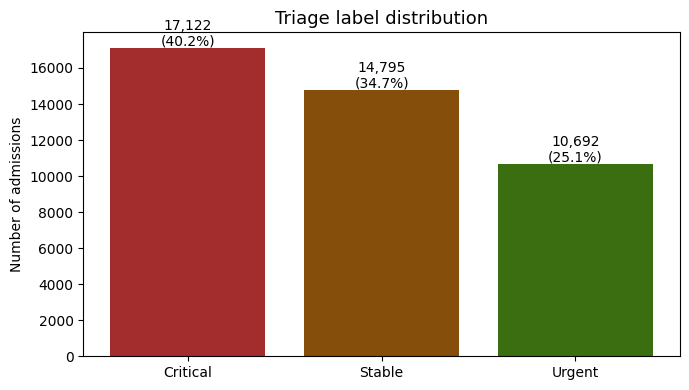

In [ ]:
# ─────────────────────────────────────────────────────────────
# Encode labels & check class balance
# ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

LABEL_MAP = {'Critical': 2, 'Urgent': 1, 'Stable': 0}
final_df['label_encoded'] = final_df['triage_label'].map(LABEL_MAP)

print("Label encoding: Critical=2, Urgent=1, Stable=0")
print(final_df['triage_label'].value_counts())

fig, ax = plt.subplots(figsize=(7, 4))
counts = final_df['triage_label'].value_counts()
colors = ['#A32D2D', '#854F0B', '#3B6D11']
ax.bar(counts.index, counts.values, color=colors)
ax.set_title('Triage label distribution', fontsize=13, fontweight='500')
ax.set_ylabel('Number of admissions')
for i, (label, val) in enumerate(counts.items()):
    ax.text(i, val + 100, f'{val:,}\n({val/len(final_df)*100:.1f}%)',
            ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/dataset/label_distribution.png', dpi=150)
plt.show()

In [ ]:
# ─────────────────────────────────────────────────────────────
# Save final dataset to Google Drive
# ─────────────────────────────────────────────────────────────

output_path = os.path.join(DATA_PATH, 'triage_dataset_final.csv')
final_df[available_features + ['triage_label', 'label_encoded']].to_csv(
    output_path, index=False
)
print(f"Dataset saved: {output_path}")
print(f"Shape: {final_df.shape}")
print(f"Total features: {len(available_features)}")

# Also save a smaller preview
preview_path = os.path.join(DATA_PATH, 'triage_dataset_preview.csv')
final_df.head(1000).to_csv(preview_path, index=False)
print(f"Preview (1000 rows) saved: {preview_path}")


Dataset saved: /content/drive/MyDrive/dataset/triage_dataset_final.csv
Shape: (42609, 95)
Total features: 88
Preview (1000 rows) saved: /content/drive/MyDrive/dataset/triage_dataset_preview.csv


In [ ]:
# ─────────────────────────────────────────────────────────────
# Quick sanity check: feature-label correlation
# ─────────────────────────────────────────────────────────────

print("Top features correlated with triage level:\n")
corr = final_df[available_features + ['label_encoded']].corr()['label_encoded']
top_pos = corr.drop('label_encoded').sort_values(ascending=False).head(15)
top_neg = corr.drop('label_encoded').sort_values(ascending=True).head(5)

print("POSITIVE (higher value → more critical):")
print(top_pos.round(3).to_string())
print("\nNEGATIVE (lower value → more critical):")
print(top_neg.round(3).to_string())


Top features correlated with triage level:

POSITIVE (higher value → more critical):
hypoxia_severe_flag      0.133
hypoxia_critical_flag    0.102
news2_score              0.084
qsofa_score              0.079
resp_rate_first          0.074
bradycardia_flag         0.072
age_elderly              0.064
sepsis_flag              0.062
age                      0.061
vt_vf_proxy              0.061
spo2_hr_combined         0.057
qsofa_rr                 0.056
tachypnea_flag           0.055
sirs_rr                  0.055
hypogly_coma_proxy       0.054

NEGATIVE (lower value → more critical):
spo2_min            -0.104
sirs_temp           -0.103
sbp_min             -0.076
news2_stable        -0.075
insurance_private   -0.052


In [ ]:
# ─────────────────────────────────────────────────────────────
# Final Merged Dataset Preview
# ─────────────────────────────────────────────────────────────

print(f"Total Patient Records in Final Dataset: {len(final_df):,}")
print(f"Total Features Available: {len(available_features)}")

# Displaying first 10 rows with key features and target label
display(final_df[['triage_label', 'age', 'gender_m', 'heart_rate_first', 'sbp_first', 'spo2_first', 'temp_f_first', 'gcs_total', 'news2_score']].head(10))

# Quick summary of the dataset structure
print("\n--- Dataset Info ---")
final_df.info(verbose=False)

Total Patient Records in Final Dataset: 42,609
Total Features Available: 88


,triage_label,age,gender_m,heart_rate_first,sbp_first,spo2_first,temp_f_first,gcs_total,news2_score
0,Stable,52,0,91.0,84.0,98.0,98.70,14.0,8
1,Stable,55,0,86.0,151.0,99.0,98.50,15.0,2
2,Critical,76,1,118.0,112.0,88.0,97.90,13.0,4
3,Critical,77,0,38.0,180.0,100.0,95.72,3.0,7
4,Critical,56,1,111.0,99.0,100.0,98.96,8.0,5
5,Critical,77,0,72.0,129.0,93.0,97.90,15.0,3
6,Stable,81,0,67.0,148.0,100.0,97.20,6.0,2
7,Critical,90,1,96.0,110.0,89.0,98.10,15.0,9
8,Critical,81,1,114.0,160.0,95.0,98.70,15.0,7
9,Stable,51,0,87.0,133.0,99.0,99.20,15.0,1



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42609 entries, 0 to 42608
Columns: 95 entries, age to label_encoded
dtypes: float64(20), int64(74), object(1)
memory usage: 30.9+ MB


### 📊 Data Source Mapping (Table-wise Columns)

| Original Table | Key Columns Used | Derived Features in Final Dataset |
| :--- | :--- | :--- |
| **Admissions** | `hadm_id`, `admission_type`, `insurance` | `is_emergency`, `is_elective`, `insurance_private` |
| **Patients** | `subject_id`, `gender`, `anchor_age`, `anchor_year` | `age`, `gender_m`, `age_elderly` |
| **Diagnoses** | `icd_code` | **`triage_label`** (Target Variable), `label_encoded` |
| **Chartevents** | `itemid`, `valuenum`, `charttime` | `heart_rate_first`, `sbp_first`, `gcs_total`, `news2_score`, `shock_index` |

**Note:** Most of the 88 features are calculated from `Chartevents` because that's where the patient's live symptoms and vitals are stored.

In [ ]:
# Train baseline model (Random Forest)

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

X = final_df[available_features].copy()
y = final_df['label_encoded'].values

# ── STEP 1: NaN fix karo (SMOTE se pehle ZARURI hai) ──────────
print(f"NaN count before impute: {X.isnull().sum().sum()}")

imputer = SimpleImputer(strategy='median')   # median se fill karo
X_imputed = imputer.fit_transform(X)

print(f"NaN count after impute:  {np.isnan(X_imputed).sum()}")

# ── STEP 2: Train/Test split ───────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42, stratify=y
)

# ── STEP 3: SMOTE (ab NaN nahi hain to chalega) ───────────────
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
print(f"After SMOTE — Train size: {X_train_res.shape[0]:,}")

# ── STEP 4: Model train ────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_res, y_train_res)

# ── STEP 5: Evaluate ───────────────────────────────────────────
y_pred = rf.predict(X_test)
print("\n=== Classification Report ===")
print(classification_report(
    y_test, y_pred,
    target_names=['Stable', 'Urgent', 'Critical']
))

NaN count before impute: 3
NaN count after impute:  0
After SMOTE — Train size: 41,091

=== Classification Report ===
              precision    recall  f1-score   support

      Stable       0.48      0.50      0.49      2959
      Urgent       0.37      0.15      0.21      2138
    Critical       0.53      0.70      0.60      3425

    accuracy                           0.49      8522
   macro avg       0.46      0.45      0.43      8522
weighted avg       0.47      0.49      0.47      8522



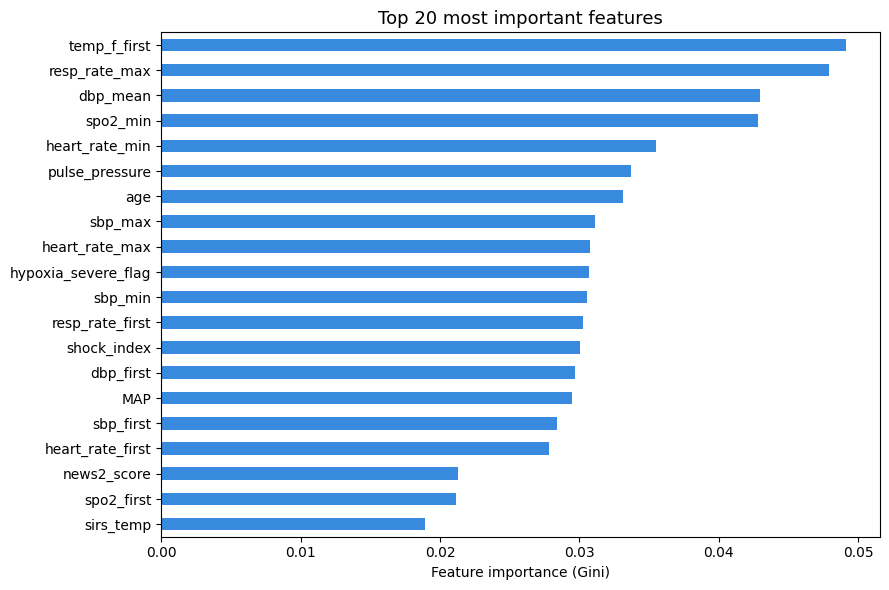

In [ ]:
# ─────────────────────────────────────────────────────────────
# Feature importance plot (top 20)
# ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

feat_imp = pd.Series(rf.feature_importances_, index=available_features)
top20 = feat_imp.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 6))
top20.sort_values().plot(kind='barh', ax=ax, color='#378ADD')
ax.set_title('Top 20 most important features', fontsize=13, fontweight='500')
ax.set_xlabel('Feature importance (Gini)')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/dataset/feature_importance.png', dpi=150)
plt.show()


In [ ]:
# ─────────────────────────────────────────────────────────────
# Save trained model to Drive
# ─────────────────────────────────────────────────────────────
import pickle

model_path = os.path.join(DATA_PATH, 'triage_rf_model.pkl')
feature_path = os.path.join(DATA_PATH, 'triage_feature_names.pkl')

with open(model_path, 'wb') as f:
    pickle.dump(rf, f)

with open(feature_path, 'wb') as f:
    pickle.dump(available_features, f)

print(f"Model saved: {model_path}")
print(f"Feature list saved: {feature_path}")
print("\nDone! Your triage system is ready.")
print(f"Total features: {len(available_features)}")
print(f"Dataset size:   {len(final_df):,} admissions")


Model saved: /content/drive/MyDrive/dataset/triage_rf_model.pkl
Feature list saved: /content/drive/MyDrive/dataset/triage_feature_names.pkl

Done! Your triage system is ready.
Total features: 88
Dataset size:   42,609 admissions
